## Goal: Segment customers into groups based on their behavior and identify which groups are more likely to contain customers at risk of churn.

## Problem Statements:


*   Which types of customers exist?
*   Which customer segment is most valuable?
*   Which segment shows high support calls/payment delays?
*   Which segment contains more churned customers?
*   What actions should the company take for each segment?







In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load The Dataset

In [2]:
df = pd.read_csv('/content/ecommerce_customer_data_custom_ratios.csv')

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37.0,0.0,Christine Hernandez,37.0,Male,0.0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49.0,0.0,James Grant,49.0,Female,1.0


In [4]:
df.shape

(12249, 13)

In [5]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12249 entries, 0 to 12248
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer ID            12249 non-null  int64  
 1   Purchase Date          12249 non-null  object 
 2   Product Category       12249 non-null  object 
 3   Product Price          12249 non-null  int64  
 4   Quantity               12249 non-null  int64  
 5   Total Purchase Amount  12249 non-null  int64  
 6   Payment Method         12249 non-null  object 
 7   Customer Age           12248 non-null  float64
 8   Returns                9969 non-null   float64
 9   Customer Name          12248 non-null  object 
 10  Age                    12248 non-null  float64
 11  Gender                 12248 non-null  object 
 12  Churn                  12248 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 1.2+ MB


In [7]:
df = df.drop(['Customer ID','Customer Age'],axis = 1)

## Understand The Data

In [8]:
df.describe()

,Product Price,Quantity,Total Purchase Amount,Returns,Age,Churn
count,12249.000000,12249.00000,12249.000000,9969.000000,12248.000000,12248.000000
mean,254.578415,2.99404,2731.559474,0.501154,43.559030,0.196359
std,141.970212,1.41163,1447.075752,0.500024,15.271269,0.397259
min,10.000000,1.00000,117.000000,0.000000,18.000000,0.000000
25%,130.000000,2.00000,1485.000000,0.000000,30.000000,0.000000
50%,256.000000,3.00000,2740.000000,1.000000,44.000000,0.000000
75%,378.000000,4.00000,3989.000000,1.000000,57.000000,0.000000
max,500.000000,5.00000,5342.000000,1.000000,70.000000,1.000000


In [9]:
df.isnull().sum()

,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Returns,2280
Customer Name,1
Age,1
Gender,1


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

,0
Purchase Date,12248
Product Category,4
Product Price,491
Quantity,5
Total Purchase Amount,4658
Payment Method,4
Returns,2
Customer Name,2040
Age,53
Gender,2


In [12]:
df.select_dtypes(include='object').columns

Index(['Purchase Date', 'Product Category', 'Payment Method', 'Customer Name',
       'Gender'],
      dtype='object')

## EDA

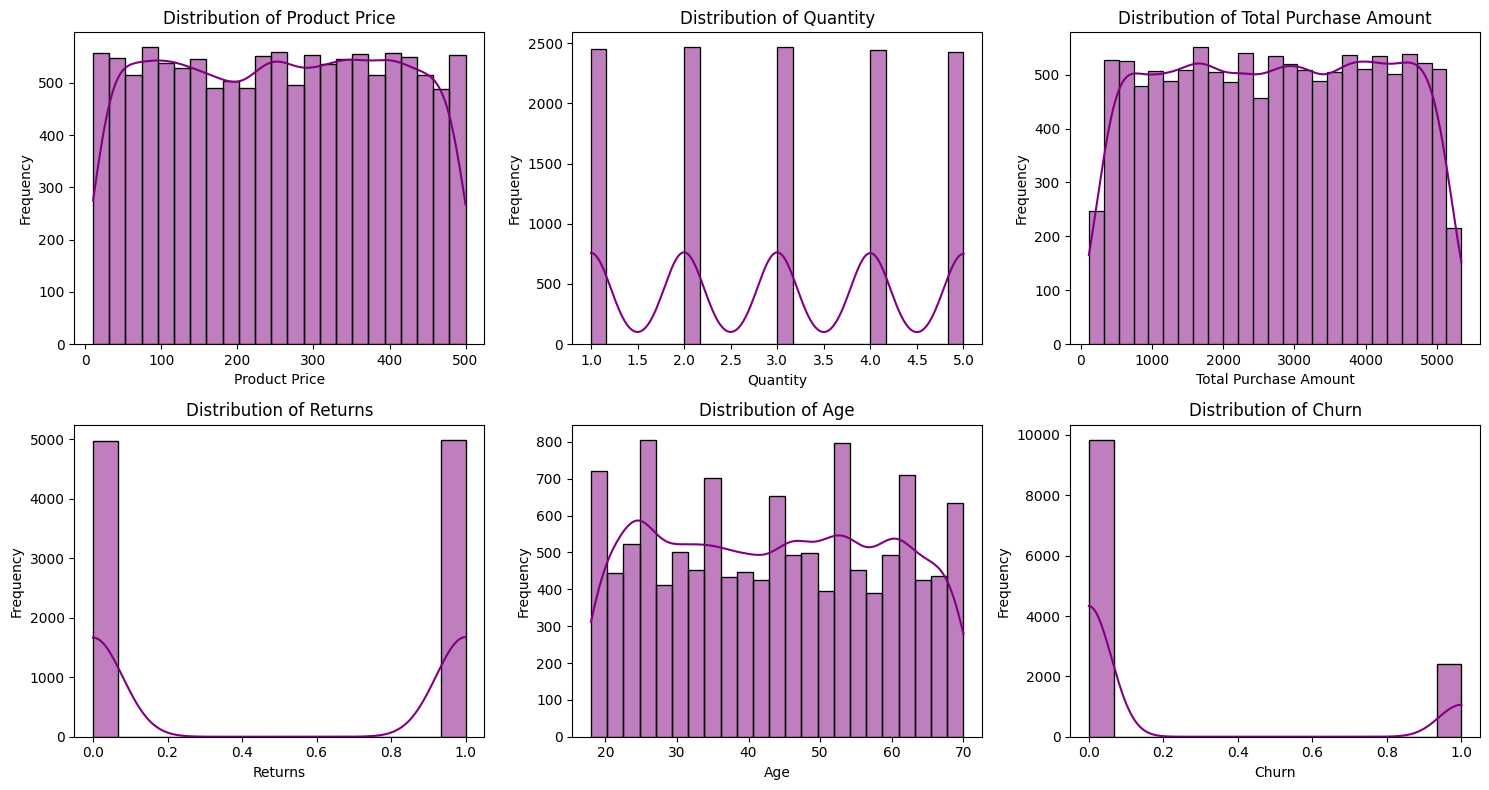

In [13]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i],color = 'purple')

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

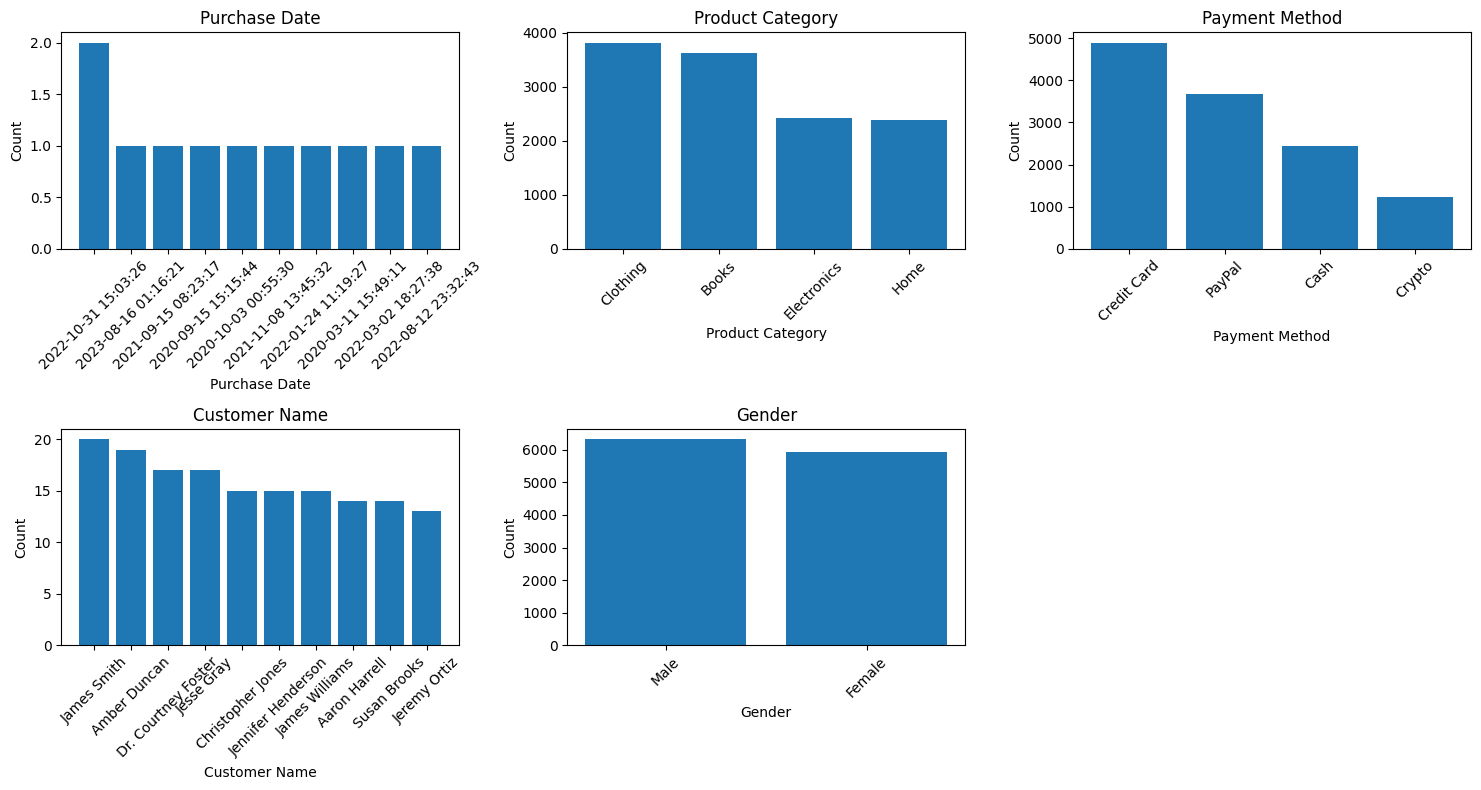

In [14]:
categorical_cols = df.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Count categories
    counts = df[col].value_counts().head(10)

    # Plot
    axes[i].bar(counts.index.astype(str), counts.values)

    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes
for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

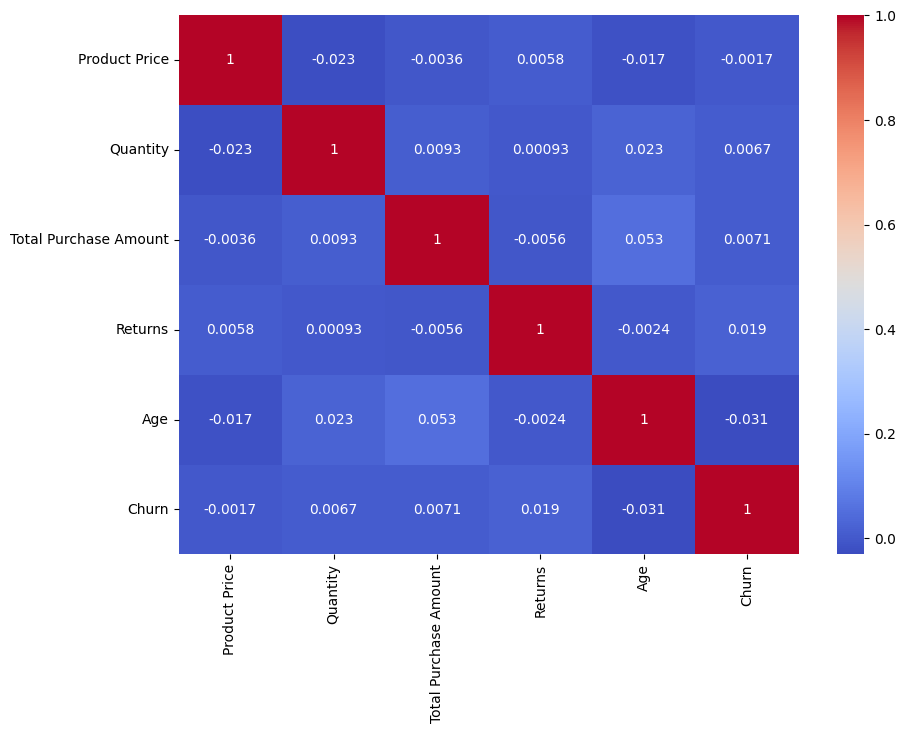

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [16]:
df['Churn'].value_counts()


,count
Churn,
0.0,9843
1.0,2405


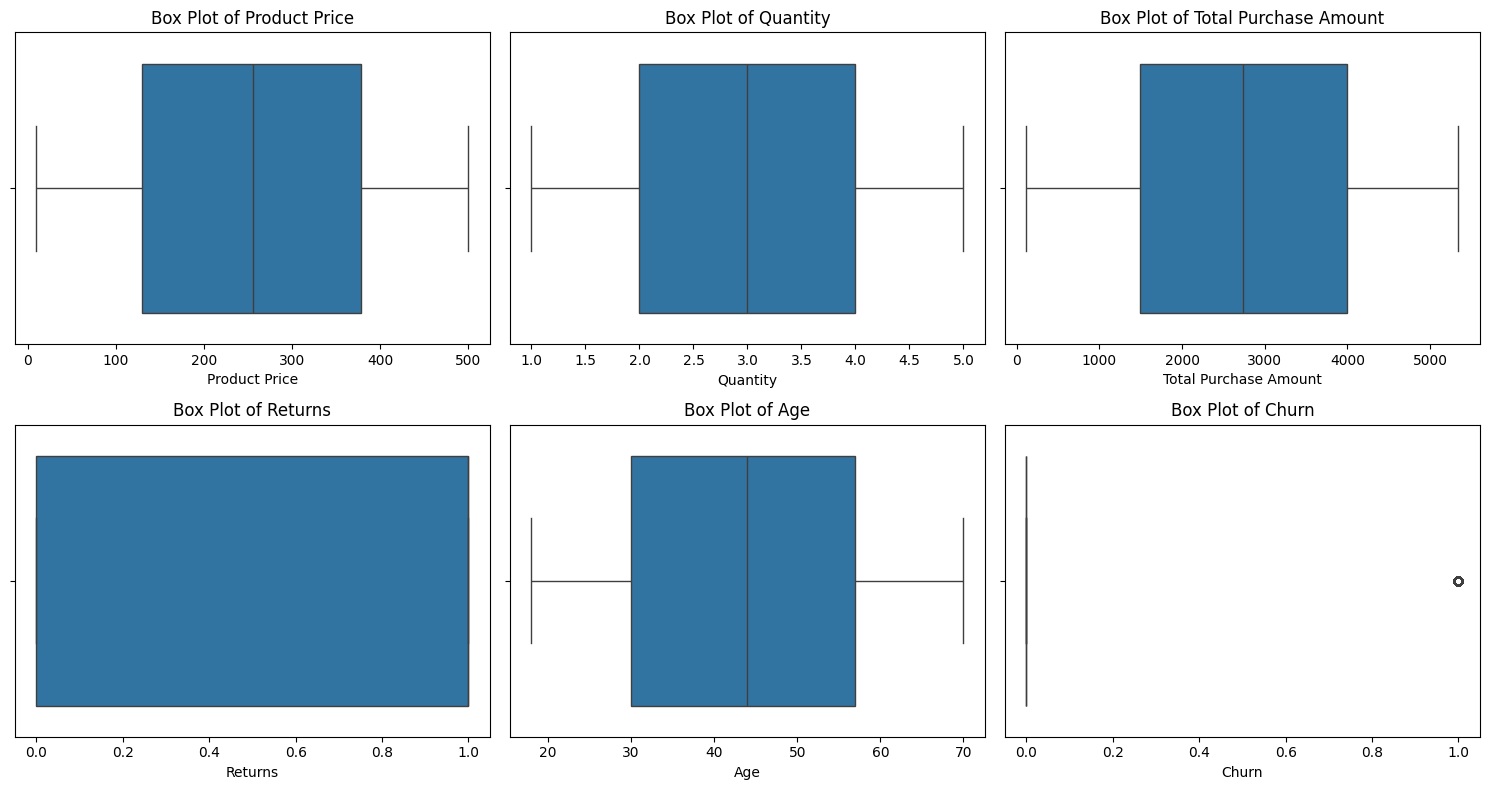

In [17]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Box Plot of {col}')

# Remove empty subplots
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [18]:
df.shape

(12249, 11)

In [19]:
df.isnull().sum()

,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Returns,2280
Customer Name,1
Age,1
Gender,1


In [20]:
df['Returns'].value_counts(dropna=False)

,count
Returns,
1.0,4996
0.0,4973
NaN,2280


In [21]:
df['Returns'].isna().sum()

np.int64(2280)

In [22]:
df[df['Returns'].isna()].describe()

,Product Price,Quantity,Total Purchase Amount,Returns,Age,Churn
count,2280.000000,2280.000000,2280.000000,0.0,2279.000000,2279.000000
mean,256.824123,2.994737,2760.664912,NaN,43.702062,0.190434
std,140.962218,1.393260,1445.336416,NaN,15.484404,0.392730
min,10.000000,1.000000,120.000000,NaN,18.000000,0.000000
25%,131.750000,2.000000,1491.750000,NaN,30.000000,0.000000
50%,259.000000,3.000000,2800.000000,NaN,44.000000,0.000000
75%,375.000000,4.000000,4020.500000,NaN,57.000000,0.000000
max,500.000000,5.000000,5322.000000,NaN,70.000000,1.000000


In [23]:
df[df['Returns'].isna()][
    ['Product Price', 'Quantity', 'Total Purchase Amount', 'Age']
].describe()

,Product Price,Quantity,Total Purchase Amount,Age
count,2280.000000,2280.000000,2280.000000,2279.000000
mean,256.824123,2.994737,2760.664912,43.702062
std,140.962218,1.393260,1445.336416,15.484404
min,10.000000,1.000000,120.000000,18.000000
25%,131.750000,2.000000,1491.750000,30.000000
50%,259.000000,3.000000,2800.000000,44.000000
75%,375.000000,4.000000,4020.500000,57.000000
max,500.000000,5.000000,5322.000000,70.000000


In [32]:
# Convert Purchase Date to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Treat missing Returns as 0
df['Returns'] = df['Returns'].fillna(0)

# Check
df[['Purchase Date', 'Returns']].head()

,Purchase Date,Returns
0,2020-09-08 09:38:32,0.0
1,2022-03-05 12:56:35,0.0
2,2022-05-23 18:18:01,0.0
3,2020-11-12 13:13:29,0.0
4,2020-11-27 17:55:11,0.0


In [33]:
customer_df = df.groupby('Customer Name').agg(

    # Number of transactions
    Frequency=('Customer Name', 'count'),

    # Total amount spent
    Monetary=('Total Purchase Amount', 'sum'),

    # Average amount spent per transaction
    Avg_Order_Value=('Total Purchase Amount', 'mean'),

    # Total number of products purchased
    Total_Quantity=('Quantity', 'sum'),

    # Average product price
    Avg_Product_Price=('Product Price', 'mean'),

    # Percentage of transactions returned
    Return_Rate=('Returns', 'mean'),

    # Customer age
    Age=('Age', 'first'),

    # Churn status
    Churn=('Churn', 'max')

).reset_index()

In [35]:
customer_df.shape

(2040, 9)

In [34]:
customer_df.head()

,Customer Name,Frequency,Monetary,Avg_Order_Value,Total_Quantity,Avg_Product_Price,Return_Rate,Age,Churn
0,Aaron Brady,6,10029,1671.500000,18,216.500000,0.500000,29.0,0.0
1,Aaron Clayton,5,16536,3307.200000,14,300.000000,0.400000,29.0,0.0
2,Aaron Harrell,14,46518,3322.714286,38,240.214286,0.428571,30.0,0.0
3,Aaron Kelley,2,8324,4162.000000,5,342.000000,0.500000,28.0,0.0
4,Aaron Padilla,4,11194,2798.500000,4,309.750000,0.750000,30.0,0.0


In [36]:
df['Customer Name'].nunique()

2040

In [37]:
customer_df.columns

Index(['Customer Name', 'Frequency', 'Monetary', 'Avg_Order_Value',
       'Total_Quantity', 'Avg_Product_Price', 'Return_Rate', 'Age', 'Churn'],
      dtype='object')

In [38]:
# Find the latest purchase date in the dataset

snapshot_date = df['Purchase Date'].max()

print("Latest Purchase Date:", snapshot_date)

Latest Purchase Date: 2023-09-15 11:50:27


In [39]:
# Find the last purchase date for every customer

recency_df = df.groupby('Customer Name').agg(
    Last_Purchase_Date=('Purchase Date', 'max')
).reset_index()

recency_df.head()

,Customer Name,Last_Purchase_Date
0,Aaron Brady,2023-04-07 16:33:50
1,Aaron Clayton,2023-09-05 09:36:09
2,Aaron Harrell,2023-01-15 22:33:10
3,Aaron Kelley,2023-04-06 02:25:19
4,Aaron Padilla,2021-11-28 15:20:37


In [40]:
# Calculate Recency

recency_df['Recency'] = (
    snapshot_date - recency_df['Last_Purchase_Date']
).dt.days

recency_df.head()

,Customer Name,Last_Purchase_Date,Recency
0,Aaron Brady,2023-04-07 16:33:50,160
1,Aaron Clayton,2023-09-05 09:36:09,10
2,Aaron Harrell,2023-01-15 22:33:10,242
3,Aaron Kelley,2023-04-06 02:25:19,162
4,Aaron Padilla,2021-11-28 15:20:37,655


In [41]:
customer_df = customer_df.merge(
    recency_df[['Customer Name', 'Recency']],
    on='Customer Name',
    how='left'
)

customer_df.head()

,Customer Name,Frequency,Monetary,Avg_Order_Value,Total_Quantity,Avg_Product_Price,Return_Rate,Age,Churn,Recency
0,Aaron Brady,6,10029,1671.500000,18,216.500000,0.500000,29.0,0.0,160
1,Aaron Clayton,5,16536,3307.200000,14,300.000000,0.400000,29.0,0.0,10
2,Aaron Harrell,14,46518,3322.714286,38,240.214286,0.428571,30.0,0.0,242
3,Aaron Kelley,2,8324,4162.000000,5,342.000000,0.500000,28.0,0.0,162
4,Aaron Padilla,4,11194,2798.500000,4,309.750000,0.750000,30.0,0.0,655


In [44]:
recency_df['Recency'] = (
    snapshot_date - recency_df['Last_Purchase_Date']
).dt.days

recency_df.head()

,Customer Name,Last_Purchase_Date,Recency
0,Aaron Brady,2023-04-07 16:33:50,160
1,Aaron Clayton,2023-09-05 09:36:09,10
2,Aaron Harrell,2023-01-15 22:33:10,242
3,Aaron Kelley,2023-04-06 02:25:19,162
4,Aaron Padilla,2021-11-28 15:20:37,655


In [45]:
customer_df = customer_df.merge(
    recency_df[['Customer Name', 'Recency']],
    on='Customer Name',
    how='left'
)

customer_df.head()

,Customer Name,Frequency,Monetary,Avg_Order_Value,Total_Quantity,Avg_Product_Price,Return_Rate,Age,Churn,Recency_x,Recency_y
0,Aaron Brady,6,10029,1671.500000,18,216.500000,0.500000,29.0,0.0,160,160
1,Aaron Clayton,5,16536,3307.200000,14,300.000000,0.400000,29.0,0.0,10,10
2,Aaron Harrell,14,46518,3322.714286,38,240.214286,0.428571,30.0,0.0,242,242
3,Aaron Kelley,2,8324,4162.000000,5,342.000000,0.500000,28.0,0.0,162,162
4,Aaron Padilla,4,11194,2798.500000,4,309.750000,0.750000,30.0,0.0,655,655


In [46]:
customer_df.shape

(2040, 11)

In [47]:
customer_df.isnull().sum()

,0
Customer Name,0
Frequency,0
Monetary,0
Avg_Order_Value,0
Total_Quantity,0
Avg_Product_Price,0
Return_Rate,0
Age,0
Churn,0
Recency_x,0


In [48]:
# Check whether both Recency columns contain the same values

(customer_df['Recency_x'] == customer_df['Recency_y']).all()

np.True_

In [49]:
customer_df = customer_df.drop(columns=['Recency_y'])

customer_df = customer_df.rename(
    columns={'Recency_x': 'Recency'}
)

In [51]:
df = customer_df

In [53]:
X = df.drop(['Churn'],axis = 1)
y = df['Churn']

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Features for customer segmentation
features = [
    'Recency',
    'Frequency',
    'Monetary',
    'Avg_Order_Value',
    'Total_Quantity',
    'Avg_Product_Price',
    'Return_Rate',
    'Age'
]

# Create X from customer-level data
X = df[features]

# Impute missing values and scale features
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_scaled = preprocessor.fit_transform(X)

print("Shape:", X_scaled.shape)

Shape: (2040, 8)


In [56]:
from  sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [57]:
silhouette_scores = {}

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores[k] = score

    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.1924
K=3 | Silhouette Score=0.1710
K=4 | Silhouette Score=0.1528
K=5 | Silhouette Score=0.1435
K=6 | Silhouette Score=0.1317
K=7 | Silhouette Score=0.1312
K=8 | Silhouette Score=0.1304
K=9 | Silhouette Score=0.1295
K=10 | Silhouette Score=0.1249


In [58]:
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print("Best K:", best_k)
print("Best Silhouette Score:", silhouette_scores[best_k])

Best K: 2
Best Silhouette Score: 0.19240523951907562


In [59]:
final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    ))
])

df['Cluster'] = final_pipeline.fit_predict(X)

In [61]:
cluster_profile = customer_df.groupby('Cluster').agg(

    Customers=('Cluster', 'size'),

    Churn_Rate=('Churn', 'mean'),

    Avg_Recency=('Recency', 'mean'),

    Avg_Frequency=('Frequency', 'mean'),

    Avg_Monetary=('Monetary', 'mean'),

    Avg_Order_Value=('Avg_Order_Value', 'mean'),

    Avg_Quantity=('Total_Quantity', 'mean'),

    Avg_Product_Price=('Avg_Product_Price', 'mean'),

    Avg_Return_Rate=('Return_Rate', 'mean'),

    Avg_Age=('Age', 'mean')
)

cluster_profile

,Customers,Churn_Rate,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value,Avg_Quantity,Avg_Product_Price,Avg_Return_Rate,Avg_Age
Cluster,,,,,,,,,,
0,1257,0.196500,255.574383,4.591090,11856.311058,2609.428065,13.431981,256.975762,0.418327,42.766905
1,783,0.209451,138.407407,8.272031,23692.088123,2896.367358,25.268199,252.331730,0.396579,44.794381
